<a href="https://colab.research.google.com/github/namharledba/Air-Quality-Prediction-Dashboard-/blob/main/DataAnalysisFile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*The File contains Cleaning and Visualization for an Air Quality Dataset*

*you can have access to The Dataset
through the link :* [Dataset](https://)


# ***Information***

---



In [38]:
from google.colab import files
import pandas as pd
from google.colab import sheets
import seaborn as sns
import matplotlib.pyplot as plt


In [39]:
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))

Saving AirQualityUCI.csv to AirQualityUCI (4).csv


In [40]:
df.head()     #first five rows

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,3/10/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,3/10/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,3/10/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,3/10/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,3/10/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [41]:
df.tail()     #last five rows

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9470,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1f-LDn2FuhANcwxx5LUqA-hHfTTtM75svteEVXn5zr-o/edit#gid=0


In [43]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,0.0,0.0
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604,NaN,NaN
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670,NaN,NaN
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,NaN,NaN
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300,NaN,NaN
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800,NaN,NaN
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200,NaN,NaN
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,NaN,NaN


# ***Cleaning***

---



In [44]:
# Check values equal to -200 for 'Time' and 'Date'
mode_value1 = df["Time"][df["Time"] != -200].mode()[0]
df["Time"] = df["Time"].replace(-200, mode_value1)
mode_value2 = df["Date"][df["Date"] != -200].mode()[0]
df["Date"] = df["Date"].replace(-200, mode_value2)

numeric_cols_with_missing_indicator = [
    'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
    'T', 'RH', 'AH'
]

for col in numeric_cols_with_missing_indicator:
    if col in df.columns:
        mean_val = df[df[col] != -200][col].mean()
        df[col] = df[col].replace(-200, mean_val)

df.dropna(axis=1, how='all', inplace=True)

df.fillna(df.mean(numeric_only=True), inplace=True)

In [45]:
df.duplicated().sum() # checking for duplication
df.drop_duplicates(inplace=True) #remove duplication
df.isnull().sum() # check after cleaning

,0
Date,1
Time,1
CO(GT),0
PT08.S1(CO),0
NMHC(GT),0
C6H6(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0


# ***Visualization***

---



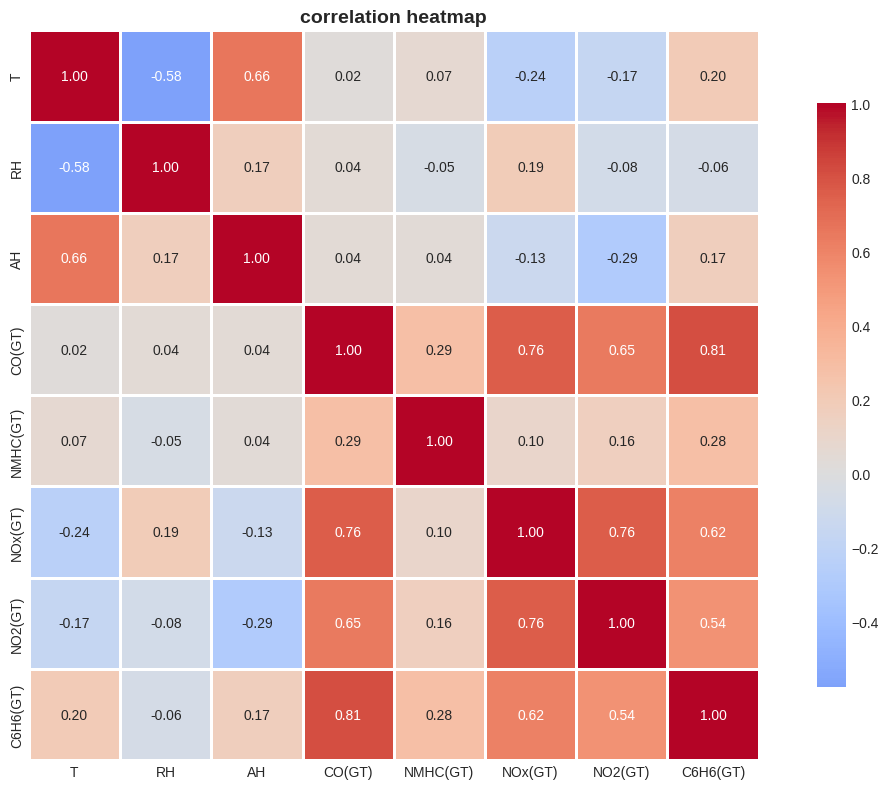

In [46]:
#heatmap
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 8))

columns_to_plot = ['T', 'RH', 'AH', 'CO(GT)', 'NMHC(GT)', 'NOx(GT)', 'NO2(GT)', 'C6H6(GT)']
correlation = df[columns_to_plot].corr()

sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})

plt.title('correlation heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

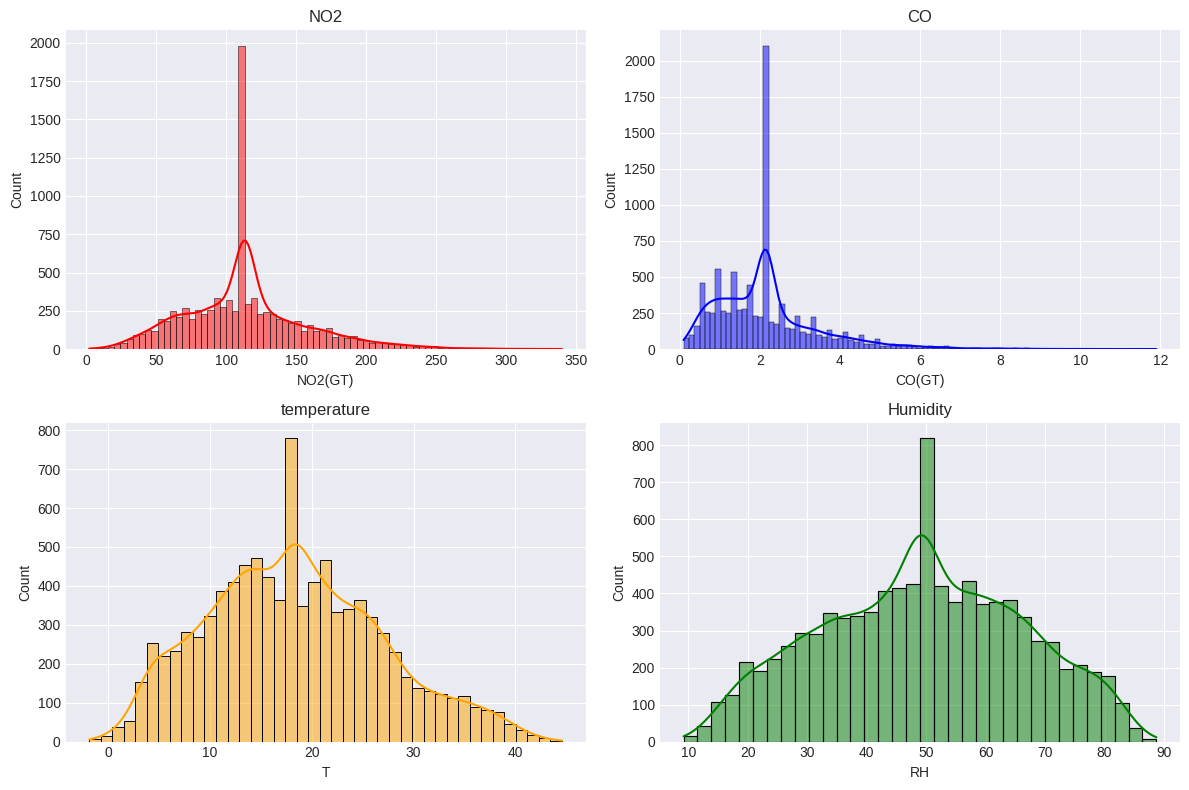

In [47]:
#histogram
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(data=df, x='NO2(GT)', kde=True, ax=axes[0, 0], color='red')
axes[0, 0].set_title('NO2')

sns.histplot(data=df, x='CO(GT)', kde=True, ax=axes[0, 1], color='blue')
axes[0, 1].set_title('CO')

sns.histplot(data=df, x='T', kde=True, ax=axes[1, 0], color='orange')
axes[1, 0].set_title('temperature')

sns.histplot(data=df, x='RH', kde=True, ax=axes[1, 1], color='green')
axes[1, 1].set_title('Humidity')

plt.tight_layout()
plt.show()

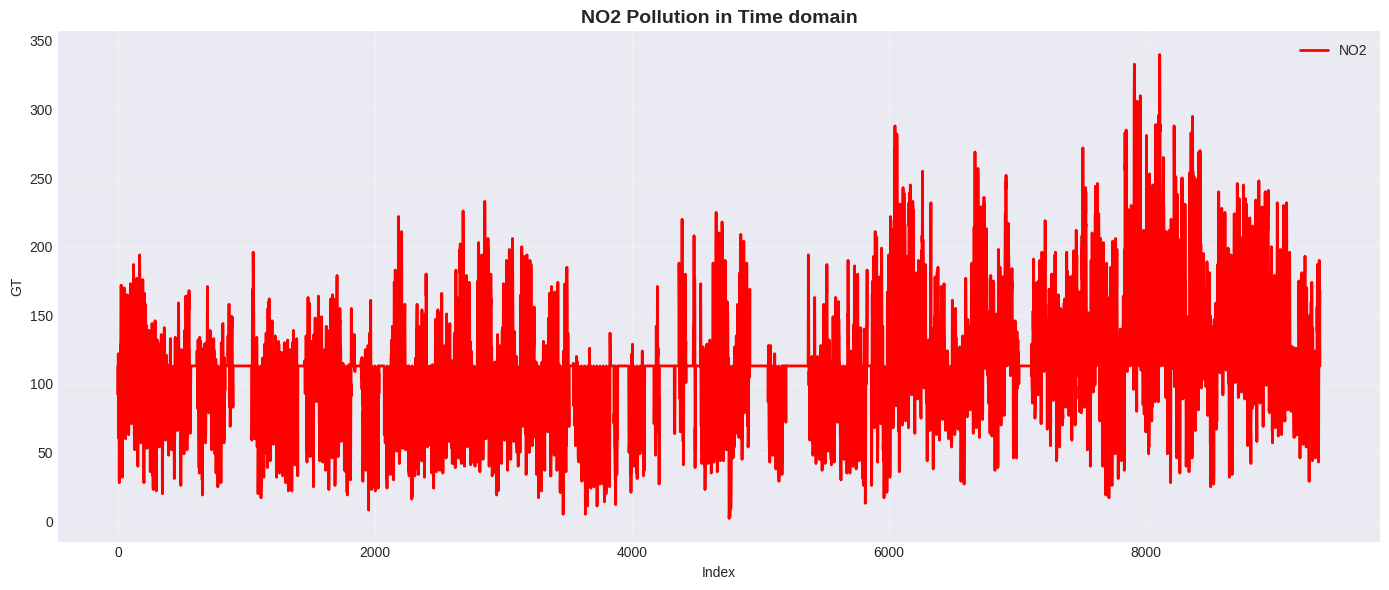

In [60]:
#NO2 Distribution
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x=df.index, y='NO2(GT)', label='NO2', linewidth=2, color = 'red')

plt.title('NO2 Pollution in Time domain', fontsize=14, fontweight='bold')
plt.xlabel('Index')
plt.ylabel('GT')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

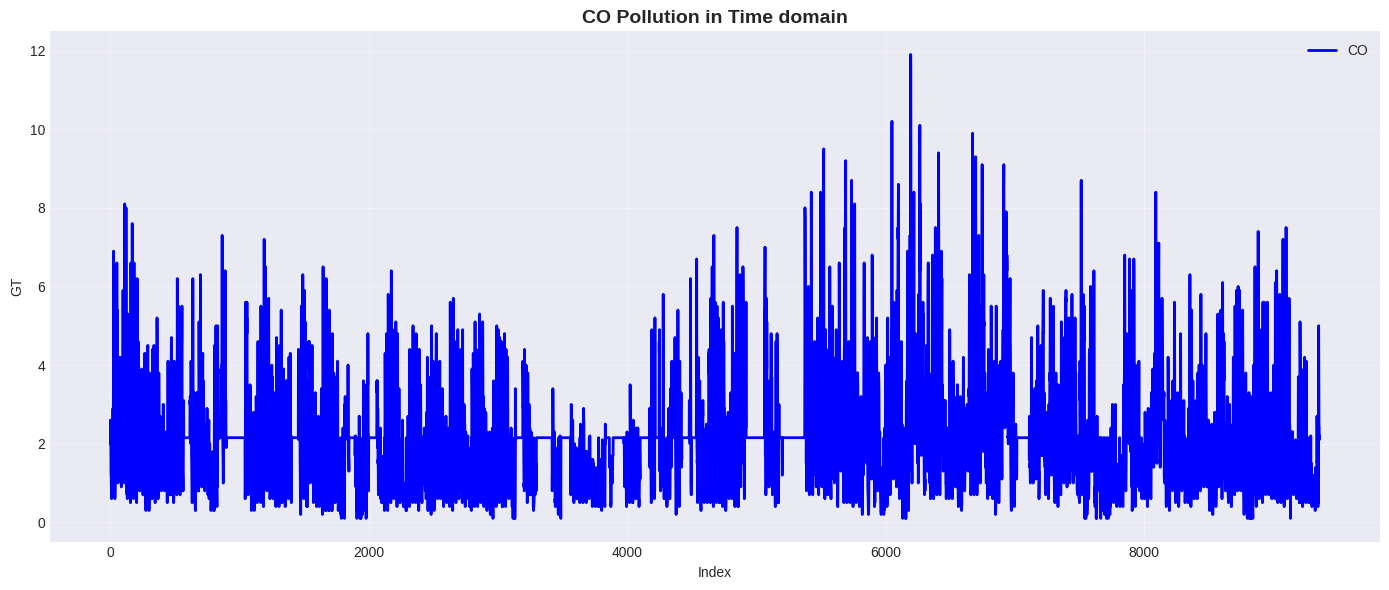

In [67]:
#CO Distribution
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x=df.index, y='CO(GT)', label='CO', linewidth=2,color = 'blue')

plt.title('CO Pollution in Time domain', fontsize=14, fontweight='bold')
plt.xlabel('Index')
plt.ylabel('GT')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

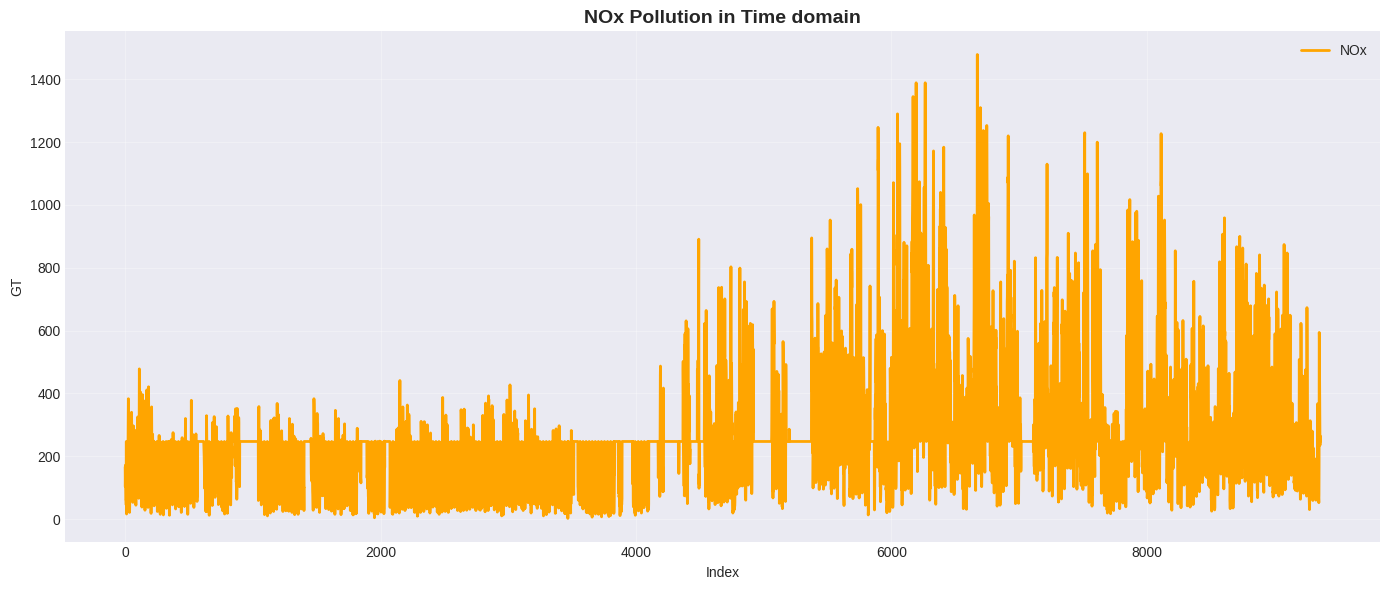

In [62]:
# NOxs distribution
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x=df.index, y='NOx(GT)', label='NOx', linewidth=2,color = 'orange')

plt.title('NOx Pollution in Time domain', fontsize=14, fontweight='bold')
plt.xlabel('Index')
plt.ylabel('GT')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

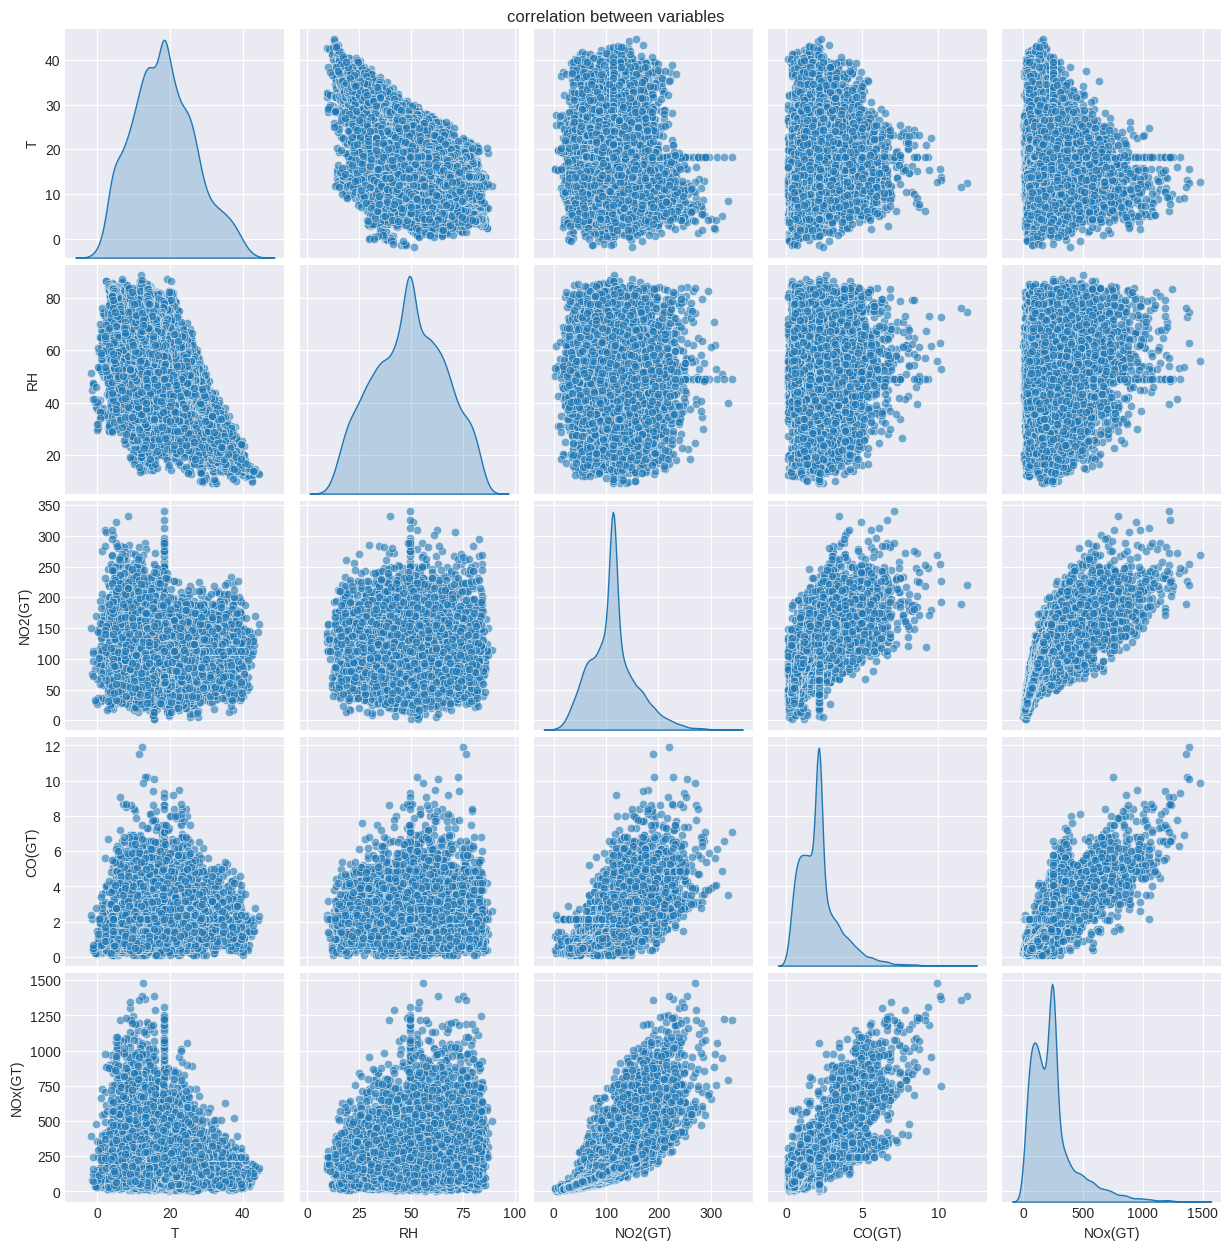

In [70]:
#pair plot
columns = ['T', 'RH', 'NO2(GT)', 'CO(GT)', 'NOx(GT)']

sns.pairplot(df[columns], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('correlation between variables', y=1.00)
plt.show()

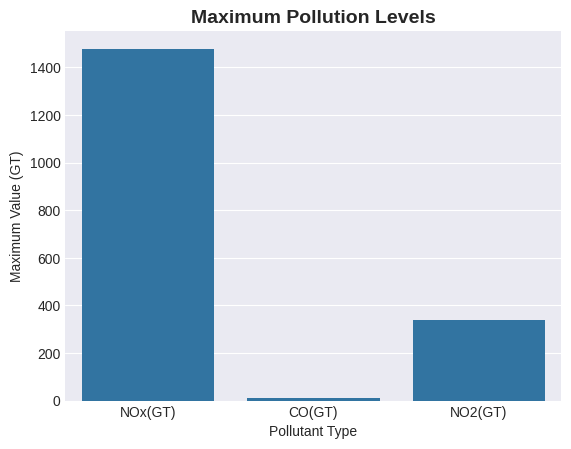

In [75]:
noxmax = df['NOx(GT)'].max()
comax = df['CO(GT)'].max()
no2max = df['NO2(GT)'].max()

max_pollution_data = pd.DataFrame({
    'Pollutant': ['NOx(GT)', 'CO(GT)', 'NO2(GT)'],
    'Max_Value': [noxmax, comax, no2max]
})

sns.barplot(
    x='Pollutant',
    y='Max_Value',
    data=max_pollution_data
)

plt.title('Maximum Pollution Levels', fontsize=14, fontweight='bold')
plt.xlabel('Pollutant Type')
plt.ylabel('Maximum Value (GT)')
plt.show()